In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/notebooks")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# 06 · Superposition: more features than dimensions (advanced)
A minimal replication of Anthropic's *Toy Models of Superposition* (Elhage et
al., 2022). A tiny autoencoder must squeeze `n` sparse features through `d < n`
dimensions. When features are **dense** it keeps only the most important ones;
when they are **sparse** it stores all of them as nearly-orthogonal directions
and accepts interference — superposition. This is the mechanism behind
"concepts are directions" and sparse autoencoders. *Primer §9.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# model: h = x W (d-dim bottleneck), x_hat = ReLU(h Wᵀ + b)
# loss:  mean over batch of Σ_i I_i (x_hat_i − x_i)²   with importances I

def forward(X, W, b):
    H = X @ W
    Z = H @ W.T + b
    return np.maximum(Z, 0.0), Z, H

def loss_and_grads(X, W, b, I):
    Bn = len(X)
    Xh, Z, H = forward(X, W, b)
    err = Xh - X
    loss = float((I * err**2).mean(0).sum())
    dZ = (2.0 / Bn) * I * err * (Z > 0)     # (B, n)
    dB = dZ.sum(0)
    dW = dZ.T @ H + X.T @ (dZ @ W)          # W appears twice: decoder + encoder
    return loss, dW, dB

## Trust nothing: numerical gradient check

In [2]:
def gradcheck():
    n, d, Bn = 5, 2, 7
    X = (rng.random((Bn, n)) < 0.5) * rng.random((Bn, n))
    W, b = rng.normal(size=(n, d)) * 0.5, rng.normal(size=n) * 0.1
    I = np.linspace(1, 0.5, n)
    _, dW, dB = loss_and_grads(X, W, b, I)
    eps, errs = 1e-6, []
    for arr, g in [(W, dW), (b, dB)]:
        num = np.zeros_like(arr)
        it = np.nditer(arr, flags=["multi_index"])
        while not it.finished:
            k = it.multi_index
            old = arr[k]
            arr[k] = old + eps; lp, *_ = loss_and_grads(X, W, b, I)
            arr[k] = old - eps; lm, *_ = loss_and_grads(X, W, b, I)
            arr[k] = old
            num[k] = (lp - lm) / (2 * eps)
            it.iternext()
        errs.append(np.abs(num - g).max())
    print(f"max |numeric − analytic|: W {errs[0]:.2e}, b {errs[1]:.2e}")
    assert max(errs) < 1e-6

gradcheck()

max |numeric − analytic|: W 2.43e-11, b 8.84e-12


## Train across sparsity levels
`n = 5` features, `d = 2` dimensions, equal importance. Each feature is active
with probability `p` (uniform magnitude when active).

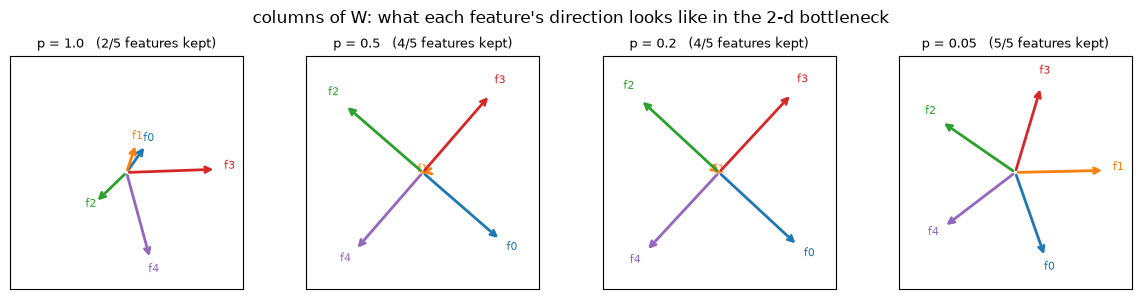

In [3]:
def sample(Bn, n, p):
    return (rng.random((Bn, n)) < p) * rng.random((Bn, n))

def train(n=5, d=2, p=0.3, steps=12000, lr=0.02, importance=None, seed=0):
    r = np.random.default_rng(seed)
    W = r.normal(size=(n, d)) * 0.3
    b = np.zeros(n)
    I = np.ones(n) if importance is None else importance
    mW = vW = 0.0; mB = vB = 0.0
    for t in range(1, steps + 1):
        X = sample(512, n, p)
        _, dW, dB = loss_and_grads(X, W, b, I)
        mW = 0.9*mW + 0.1*dW;  vW = 0.999*vW + 0.001*dW**2
        mB = 0.9*mB + 0.1*dB;  vB = 0.999*vB + 0.001*dB**2
        lr_t = lr * 0.5 * (1 + np.cos(np.pi * t / steps))   # cosine decay
        W -= lr_t * (mW/(1-0.9**t)) / (np.sqrt(vW/(1-0.999**t)) + 1e-8)
        b -= lr_t * (mB/(1-0.9**t)) / (np.sqrt(vB/(1-0.999**t)) + 1e-8)
    return W, b

ps = [1.0, 0.5, 0.2, 0.05]
fig, axes = plt.subplots(1, len(ps), figsize=(3 * len(ps), 3))
for ax, p in zip(axes, ps):
    W, _ = train(p=p)
    for i in range(len(W)):
        ax.annotate("", xy=W[i], xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=f"C{i}", lw=2))
        ax.annotate(f"f{i}", W[i] * 1.15, color=f"C{i}", ha="center", fontsize=8)
    lim = max(1.1, np.abs(W).max() * 1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    n_alive = int((np.linalg.norm(W, axis=1) > 0.6).sum())
    ax.set_title(f"p = {p}   ({n_alive}/5 features kept)", fontsize=9)
plt.suptitle("columns of W: what each feature's direction looks like in the 2-d bottleneck")
plt.tight_layout(); plt.show()

Dense regime (p=1): only ~2 features get directions — the rest are dropped
(PCA-like behaviour). Sparse regime: all 5 survive at equal norm, packed as
the famous pentagon. The model represents **5 things in 2 dimensions**
because they rarely co-occur.

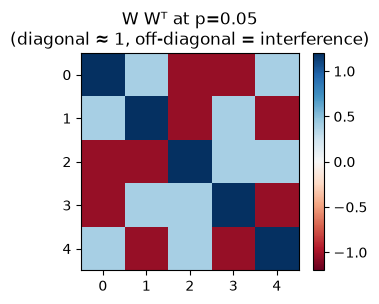

mean |interference| = 0.576  (the price of superposition)


In [4]:
W, _ = train(p=0.05)
G = W @ W.T
plt.figure(figsize=(3.5, 3))
plt.imshow(G, cmap="RdBu", vmin=-1.2, vmax=1.2)
plt.colorbar(); plt.title("W Wᵀ at p=0.05\n(diagonal ≈ 1, off-diagonal = interference)")
plt.tight_layout(); plt.show()
off = G - np.diag(np.diag(G))
print(f"mean |interference| = {np.abs(off).mean():.3f}  (the price of superposition)")

## Importance decides who gets a clean dimension

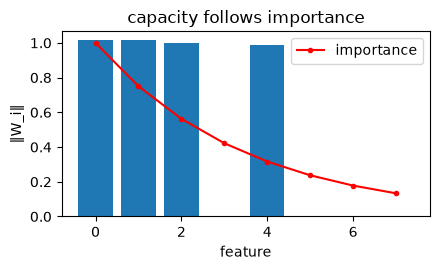

In [5]:
imp = 0.75 ** np.arange(8)
W, _ = train(n=8, d=2, p=0.15, importance=imp, seed=0)
norms = np.linalg.norm(W, axis=1)
plt.figure(figsize=(4.5, 2.8))
plt.bar(range(8), norms, color="C0")
plt.plot(range(8), imp, "r.-", label="importance")
plt.xlabel("feature"); plt.ylabel("‖W_i‖"); plt.legend()
plt.title("capacity follows importance"); plt.tight_layout(); plt.show()

**Takeaways.** (1) With sparse features, a `d`-dim space holds far more than
`d` concepts as *directions* — exactly the linear-representation picture from
§9, and why analogies and steering work. (2) Interference is the tax; sparse
autoencoders are the attempt to un-mix it. (3) Nearly-orthogonal packings are
a JL-lemma story (notebook 03): exponentially many almost-orthogonal
directions exist. → `exercises/ex06.ipynb`.